In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "font.size": 10,
    "axes.edgecolor": "#4d4d4d",
    "grid.alpha": 0.3,
})

NOT_DROPOUT_COLOR = "#4C72B0"
DROPOUT_COLOR = "#DD8452"

In [15]:
# Read the raw file as plain text first, bypass pandas entirely for this step
with open("dataset_school_dropout.csv", "r", encoding="utf-8-sig") as f:
    raw_text = f.read()

# Remove every literal quote character -- none of this dataset's actual values
# need quoting (no field contains a semicolon or comma inside it), so this is safe
raw_text = raw_text.replace('"', '')

# Now parse the CLEANED text as semicolon-separated
import io
df = pd.read_csv(io.StringIO(raw_text), sep=";", engine="python")

import re
df.columns = [re.sub(r'\s+', ' ', col).strip() for col in df.columns]

print(df.shape)
for col in df.columns:
    print(repr(col))

(4424, 37)
'Marital status'
'Application mode'
'Application order'
'Course'
'Daytime/evening attendance'
'Previous qualification'
'Previous qualification (grade)'
'Nacionality'
"Mother's qualification"
"Father's qualification"
"Mother's occupation"
"Father's occupation"
'Admission grade'
'Displaced'
'Educational special needs'
'Debtor'
'Tuition fees up to date'
'Gender'
'Scholarship holder'
'Age at enrollment'
'International'
'Curricular units 1st sem (credited)'
'Curricular units 1st sem (enrolled)'
'Curricular units 1st sem (evaluations)'
'Curricular units 1st sem (approved)'
'Curricular units 1st sem (grade)'
'Curricular units 1st sem (without evaluations)'
'Curricular units 2nd sem (credited)'
'Curricular units 2nd sem (enrolled)'
'Curricular units 2nd sem (evaluations)'
'Curricular units 2nd sem (approved)'
'Curricular units 2nd sem (grade)'
'Curricular units 2nd sem (without evaluations)'
'Unemployment rate'
'Inflation rate'
'GDP'
'Target'


In [16]:
# Now your original code will work perfectly without the extra quote
print("Shape:", df.shape)
print()
print("Missing values:", df.isnull().sum().sum())
print()
print("Target class balance:")
print(df["Target"].value_counts())
print(df["Target"].value_counts(normalize=True).round(3))

Shape: (4424, 37)

Missing values: 0

Target class balance:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64
Target
Graduate    0.499
Dropout     0.321
Enrolled    0.179
Name: proportion, dtype: float64


In [17]:
# --- Course -> Nigerian-equivalent programs ---
course_map = {
    171: "Biotechnology",
    9254: "Computer Science",
    9070: "Social Work",
    9773: "Agricultural Science",
    8014: "Mass Communication",
    9991: "Veterinary Medicine",
    9500: "Computer Engineering",
    9238: "Animal Science",
    9670: "Business Administration",
    9853: "Social Work",
    9085: "Hospitality Management",
    9130: "Nursing Science",
    9556: "Dental Technology",
    9147: "Marketing",
    9003: "Mass Communication",
    33: "Primary Education",
    9119: "Business Administration"
}

df["Course_Nigerian"] = df["Course"].map(course_map)

In [18]:
print(df["Course_Nigerian"].isna().sum())

0


In [19]:
# --- Previous qualification -> Nigerian education-level equivalents ---
qualification_map = {
    1: "SSCE (WAEC/NECO)", 2: "OND / HND", 3: "Bachelor's Degree",
    4: "Master's Degree", 5: "Doctorate", 6: "Currently in Tertiary Education",
    7: "SS3 - Not Completed", 8: "SS2 - Not Completed",
    9: "Other Secondary-Level Certificate", 10: "SS1 Completed",
    11: "SS1 - Not Completed", 12: "JSS3 or Equivalent",
    13: "JSS1/JSS2 or Equivalent", 14: "Technical/Vocational Certificate",
    15: "Bachelor's Degree (Polytechnic)",
    16: "Professional Higher Technical Certificate",
    17: "Master's Degree (2nd Cycle)",
}

parent_qualification_map = {
    1: "SSCE (WAEC/NECO)", 2: "Bachelor's Degree", 3: "Bachelor's Degree",
    4: "Master's Degree", 5: "Doctorate", 6: "Currently in Tertiary Education",
    7: "SS3 - Not Completed", 8: "SS2 - Not Completed", 9: "Primary Education (Old System)",
    10: "SS1 - Not Completed", 11: "JSS2 Completed", 12: "SS1 Completed",
    13: "Technical/Vocational Certificate", 14: "JSS3 or Equivalent",
    15: "Technical Secondary Certificate", 16: "Technical/Vocational Certificate",
    17: "Technical Secondary Certificate - Not Completed", 18: "JSS1 Completed",
    19: "JSS2 (Old System)", 20: "JSS3 - Not Completed", 21: "Primary 6 Completed",
    22: "Commerce Certificate", 23: "Accounting/Admin Certificate", 24: "Unknown",
    25: "No Formal Education", 26: "Non-formal Literacy (No Certificate)",
    27: "Primary Education (Partial)", 28: "Primary Education Completed",
    29: "Technical/Vocational Certificate", 30: "Bachelor's Degree (Polytechnic)",
    31: "Specialized Higher Studies", 32: "Professional Higher Technical Certificate",
    33: "Master's Degree", 34: "Doctorate",
}

df["Previous qualification"] = df["Previous qualification"].map(qualification_map)
df["Mother's qualification"] = df["Mother's qualification"].map(parent_qualification_map)
df["Father's qualification"] = df["Father's qualification"].map(parent_qualification_map)

In [20]:
# --- Nationality -> collapse to Nigerian / Non-Nigerian ---
# 99.8% of the source data is a single nationality, so this preserves that
# structure meaningfully in a single-country context.

df["Nationality"] = df["Nacionality"].apply(lambda x: "Nigerian" if x == 1 else "Non-Nigerian")

df = df.drop(columns=["Nacionality"])

In [21]:
# --- Straightforward binary/categorical relabels ---
# Clean column names
df.columns = (
    df.columns
    .str.replace("\ufeff", "", regex=False)
    .str.strip()
    .str.strip('"')
)

# Daytime / Evening
df["Daytime/evening attendance"] = df["Daytime/evening attendance"].map({
    1: "Daytime",
    0: "Evening"
})

# Gender
df["Gender"] = df["Gender"].map({
    1: "Male",
    0: "Female"
})

# Yes / No columns
for col in [
    "Displaced",
    "Educational special needs",
    "Debtor",
    "Tuition fees up to date",
    "Scholarship holder",
    "International"
]:
    df[col] = df[col].map({
        1: "Yes",
        0: "No"
    })

# Marital status
marital_map = {
    1: "Single",
    2: "Married",
    3: "Widowed",
    4: "Divorced",
    5: "Cohabiting",
    6: "Legally Separated"
}

df["Marital status"] = df["Marital status"].map(marital_map)

In [22]:
# Portugal's 0-20 grading scale -> Nigerian 0-100 percentage scale
for col in ["Curricular units 1st sem (grade)", "Curricular units 2nd sem (grade)"]:
    df[col] = (df[col] * 5).round(1)

df[["Curricular units 1st sem (grade)", "Curricular units 2nd sem (grade)"]].describe()

,Curricular units 1st sem (grade),Curricular units 2nd sem (grade)
count,4424.000000,4424.000000
mean,53.204091,51.150769
std,24.218462,26.053983
min,0.000000,0.000000
25%,55.000000,53.800000
50%,61.400000,61.000000
75%,67.000000,66.700000
max,94.400000,92.900000


In [23]:
nigeria_macro_by_year = {
    # year: (unemployment %, inflation %, GDP growth %)
    2009: (5.092, 12.50, 8.04),   # unemployment: no NBS pre-2010 figure, proxied with 2010 value
    2010: (5.092, 13.70, 9.13),
    2011: (5.957, 10.80, 5.13),
    2012: (10.566, 12.20, 4.21),
    2013: (9.955, 8.50, 5.49),
    2014: (7.841, 8.00, 6.22),
    2015: (9.000, 9.00, 2.79),
    2016: (13.375, 15.70, -1.58),
    2017: (17.462, 15.37, 0.82),
    2018: (22.562, 11.44, 1.91),
}

# Rank-match: sort source (Portugal) combos and target (Nigeria) years both
# by GDP growth ascending, then pair them 1-to-1.
source_combos = (
    df[["Unemployment rate", "Inflation rate", "GDP"]]
    .drop_duplicates()
    .sort_values("GDP")
    .reset_index(drop=True)
)
nigeria_years_sorted = sorted(nigeria_macro_by_year, key=lambda y: nigeria_macro_by_year[y][2])
combo_to_year = {
    tuple(row): nigeria_years_sorted[i]
    for i, row in enumerate(source_combos.itertuples(index=False))
}

def map_macro(row):
    year = combo_to_year[(row["Unemployment rate"], row["Inflation rate"], row["GDP"])]
    unemp, infl, gdp = nigeria_macro_by_year[year]
    return pd.Series({"Enrollment year (approx.)": year,
                       "Unemployment rate (%)": unemp,
                       "Inflation rate (%)": infl,
                       "GDP growth (%)": gdp})

df = df.join(df.apply(map_macro, axis=1))
df = df.drop(columns=["Unemployment rate", "Inflation rate", "GDP"])

df[["Enrollment year (approx.)", "Unemployment rate (%)", "Inflation rate (%)", "GDP growth (%)"]].drop_duplicates().sort_values("Enrollment year (approx.)")

,Enrollment year (approx.),Unemployment rate (%),Inflation rate (%),GDP growth (%)
20,2009.0,5.092,12.50,8.04
9,2010.0,5.092,13.70,9.13
1,2011.0,5.957,10.80,5.13
25,2012.0,10.566,12.20,4.21
0,2013.0,9.955,8.50,5.49
33,2014.0,7.841,8.00,6.22
5,2015.0,9.000,9.00,2.79
6,2016.0,13.375,15.70,-1.58
3,2017.0,17.462,15.37,0.82
11,2018.0,22.562,11.44,1.91


In [24]:
df["Dropout"] = (df["Target"] == "Dropout").astype(int)

print("Binary target balance:")
print(df["Dropout"].value_counts(normalize=True).round(3))

Binary target balance:
Dropout
0    0.679
1    0.321
Name: proportion, dtype: float64


In [27]:
df["Dropout_label"] = df["Dropout"].map({1: "Dropout", 0: "Not Dropout"})

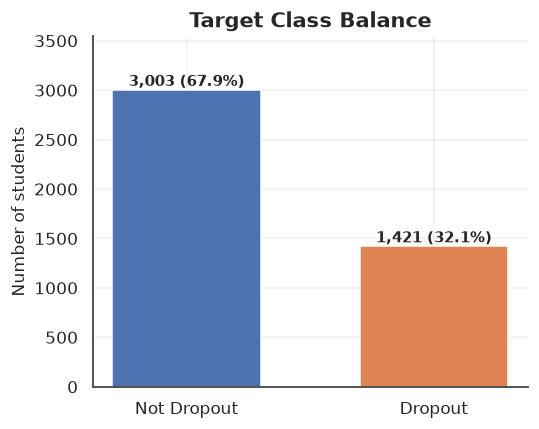

In [28]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = df["Dropout_label"].value_counts().reindex(["Not Dropout", "Dropout"])
bars = ax.bar(counts.index, counts.values,
              color=[NOT_DROPOUT_COLOR, DROPOUT_COLOR], width=0.6, edgecolor="white")
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 40, f"{v:,} ({v / len(df):.1%})",
            ha="center", fontsize=10, fontweight="bold")
ax.set_title("Target Class Balance")
ax.set_ylabel("Number of students")
ax.set_ylim(0, counts.max() * 1.18)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

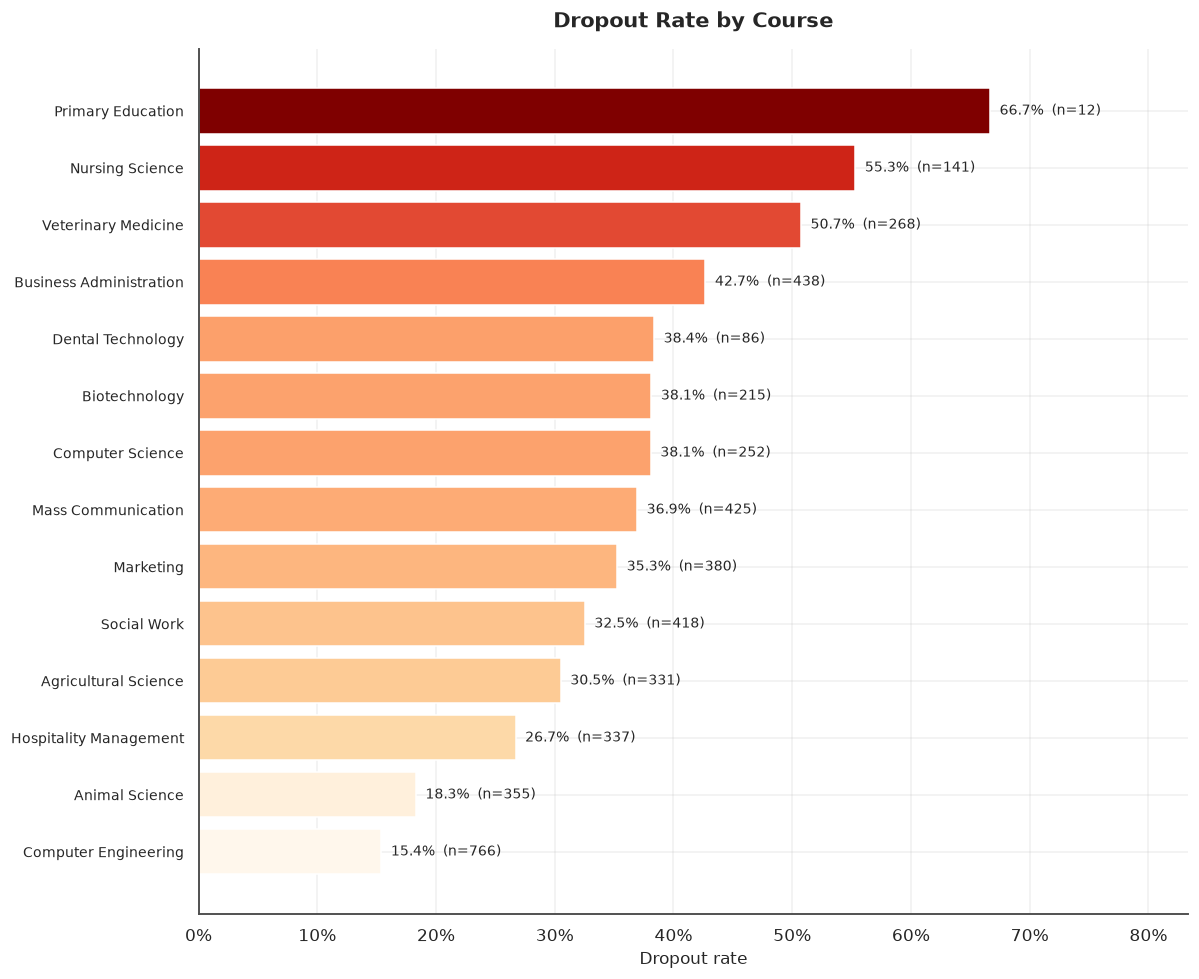

Highest-dropout course: Primary Education (66.7%)
Lowest-dropout course: Computer Engineering (15.4%)


In [29]:
course_rate = (
    df.groupby("Course_Nigerian")["Dropout"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)

fig, ax = plt.subplots(figsize=(11, 9))

norm = plt.Normalize(course_rate["mean"].min(), course_rate["mean"].max())
colors = plt.cm.OrRd(norm(course_rate["mean"]))

bars = ax.barh(course_rate.index, course_rate["mean"], color=colors, edgecolor="white")
ax.invert_yaxis()

ax.set_xlabel("Dropout rate")
ax.set_ylabel("")
ax.set_title("Dropout Rate by Course", pad=14)

for bar, (rate, n) in zip(bars, zip(course_rate["mean"], course_rate["count"])):
    ax.text(bar.get_width() + 0.008, bar.get_y() + bar.get_height() / 2,
            f"{rate:.1%}  (n={n})", va="center", fontsize=9)

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.set_xlim(0, course_rate["mean"].max() * 1.25)
ax.tick_params(axis="y", labelsize=9)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()



print(f"Highest-dropout course: {course_rate.index[0]} ({course_rate['mean'].iloc[0]:.1%})")
print(f"Lowest-dropout course: {course_rate.index[-1]} ({course_rate['mean'].iloc[-1]:.1%})")

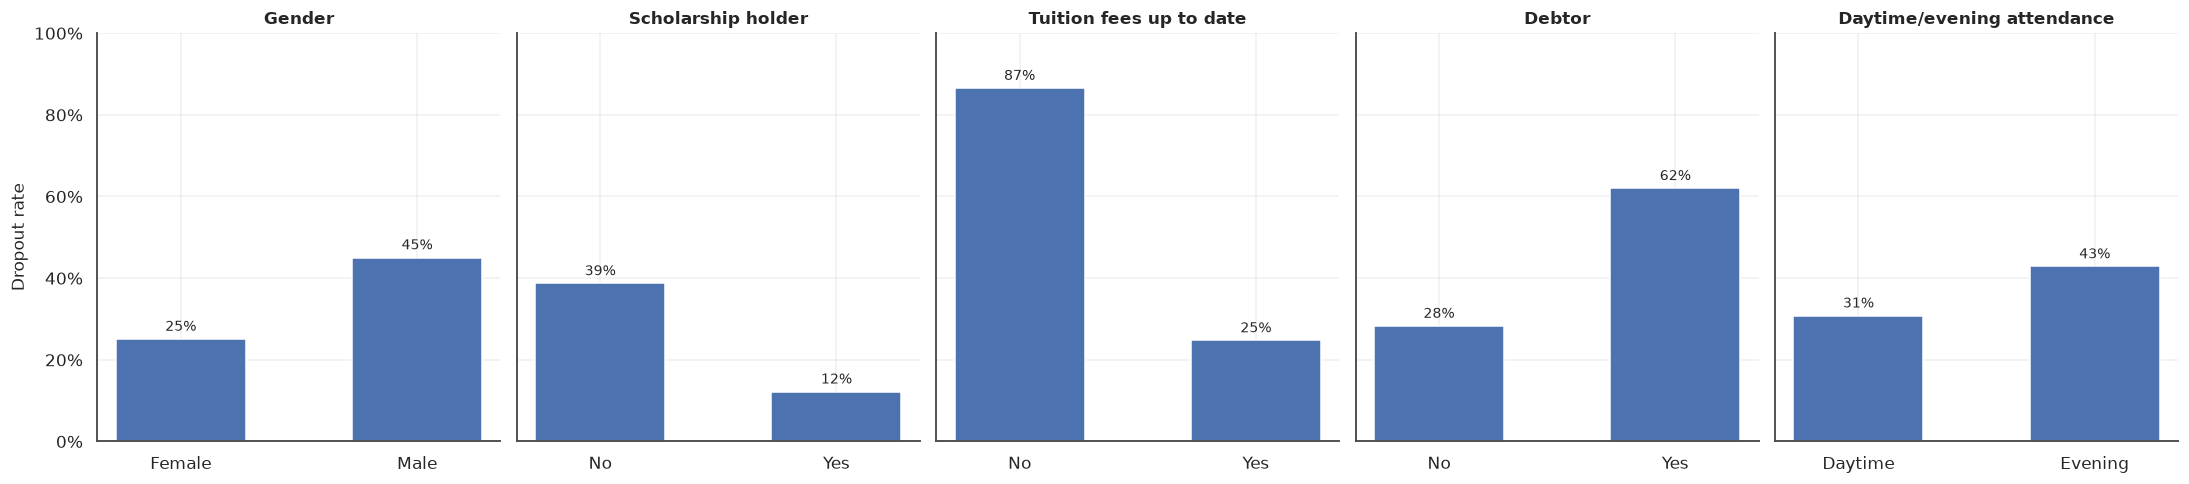

In [30]:
cat_features = ["Gender", "Scholarship holder", "Tuition fees up to date",
                 "Debtor", "Daytime/evening attendance"]

fig, axes = plt.subplots(1, len(cat_features), figsize=(20, 4.5), sharey=True)
for ax, col in zip(axes, cat_features):
    rate = df.groupby(col)["Dropout"].mean().sort_index()
    # I use one consistent color here rather than a per-panel auto-normalized
    # palette, since these bars represent a rate (not a Dropout/Not-Dropout
    # comparison) — a gradient that re-normalizes per panel would visually
    # imply a meaning that isn't actually there.
    bars = ax.bar(rate.index, rate.values, color=NOT_DROPOUT_COLOR, width=0.55, edgecolor="white")
    for bar, v in zip(bars, rate.values):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.02, f"{v:.0%}",
                ha="center", fontsize=9)
    ax.set_title(col, fontsize=11)
    ax.set_ylabel("Dropout rate" if ax is axes[0] else "")
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

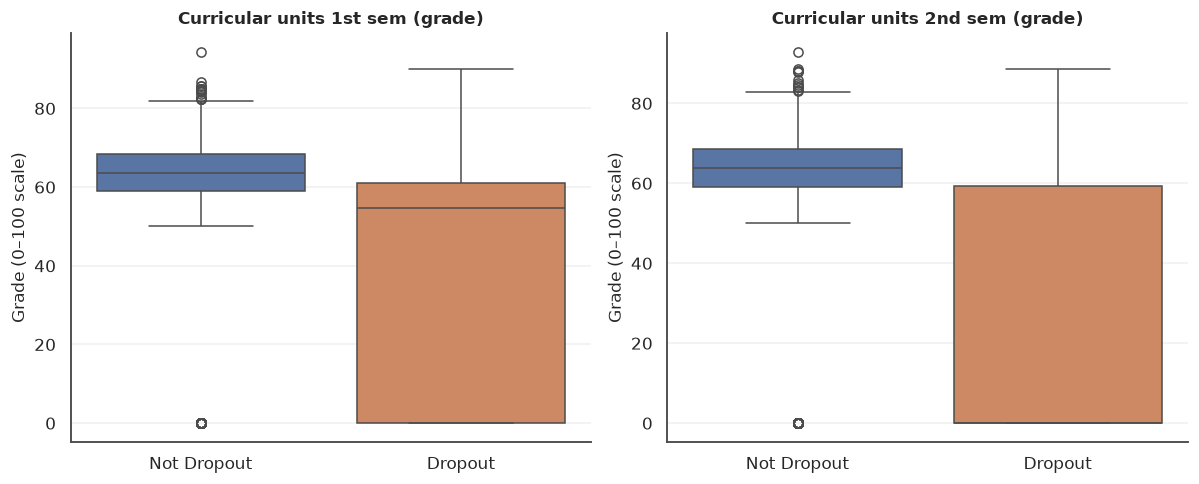

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, col in zip(axes, ["Curricular units 1st sem (grade)", "Curricular units 2nd sem (grade)"]):
    sns.boxplot(data=df, x="Dropout_label", y=col, hue="Dropout_label",
                order=["Not Dropout", "Dropout"], hue_order=["Not Dropout", "Dropout"],
                palette=[NOT_DROPOUT_COLOR, DROPOUT_COLOR], ax=ax, legend=False)
    ax.set_title(col, fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("Grade (0–100 scale)")
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

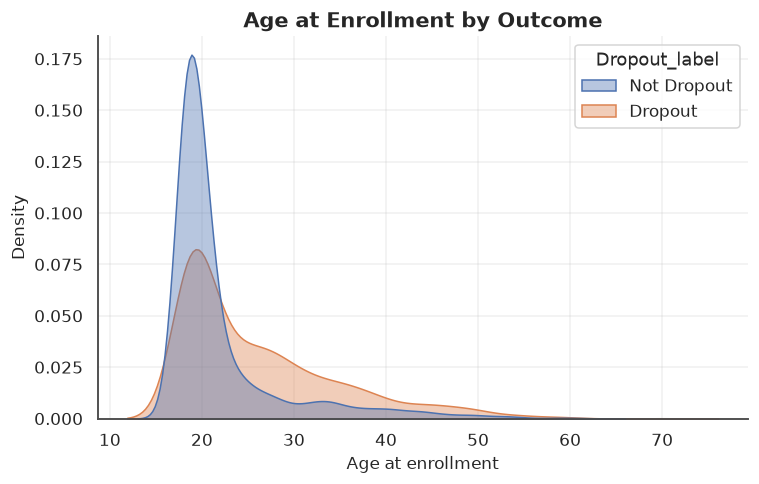

In [32]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.kdeplot(data=df, x="Age at enrollment", hue="Dropout_label",
            hue_order=["Not Dropout", "Dropout"],
            fill=True, common_norm=False, alpha=0.4, ax=ax,
            palette=[NOT_DROPOUT_COLOR, DROPOUT_COLOR])
ax.set_title("Age at Enrollment by Outcome")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

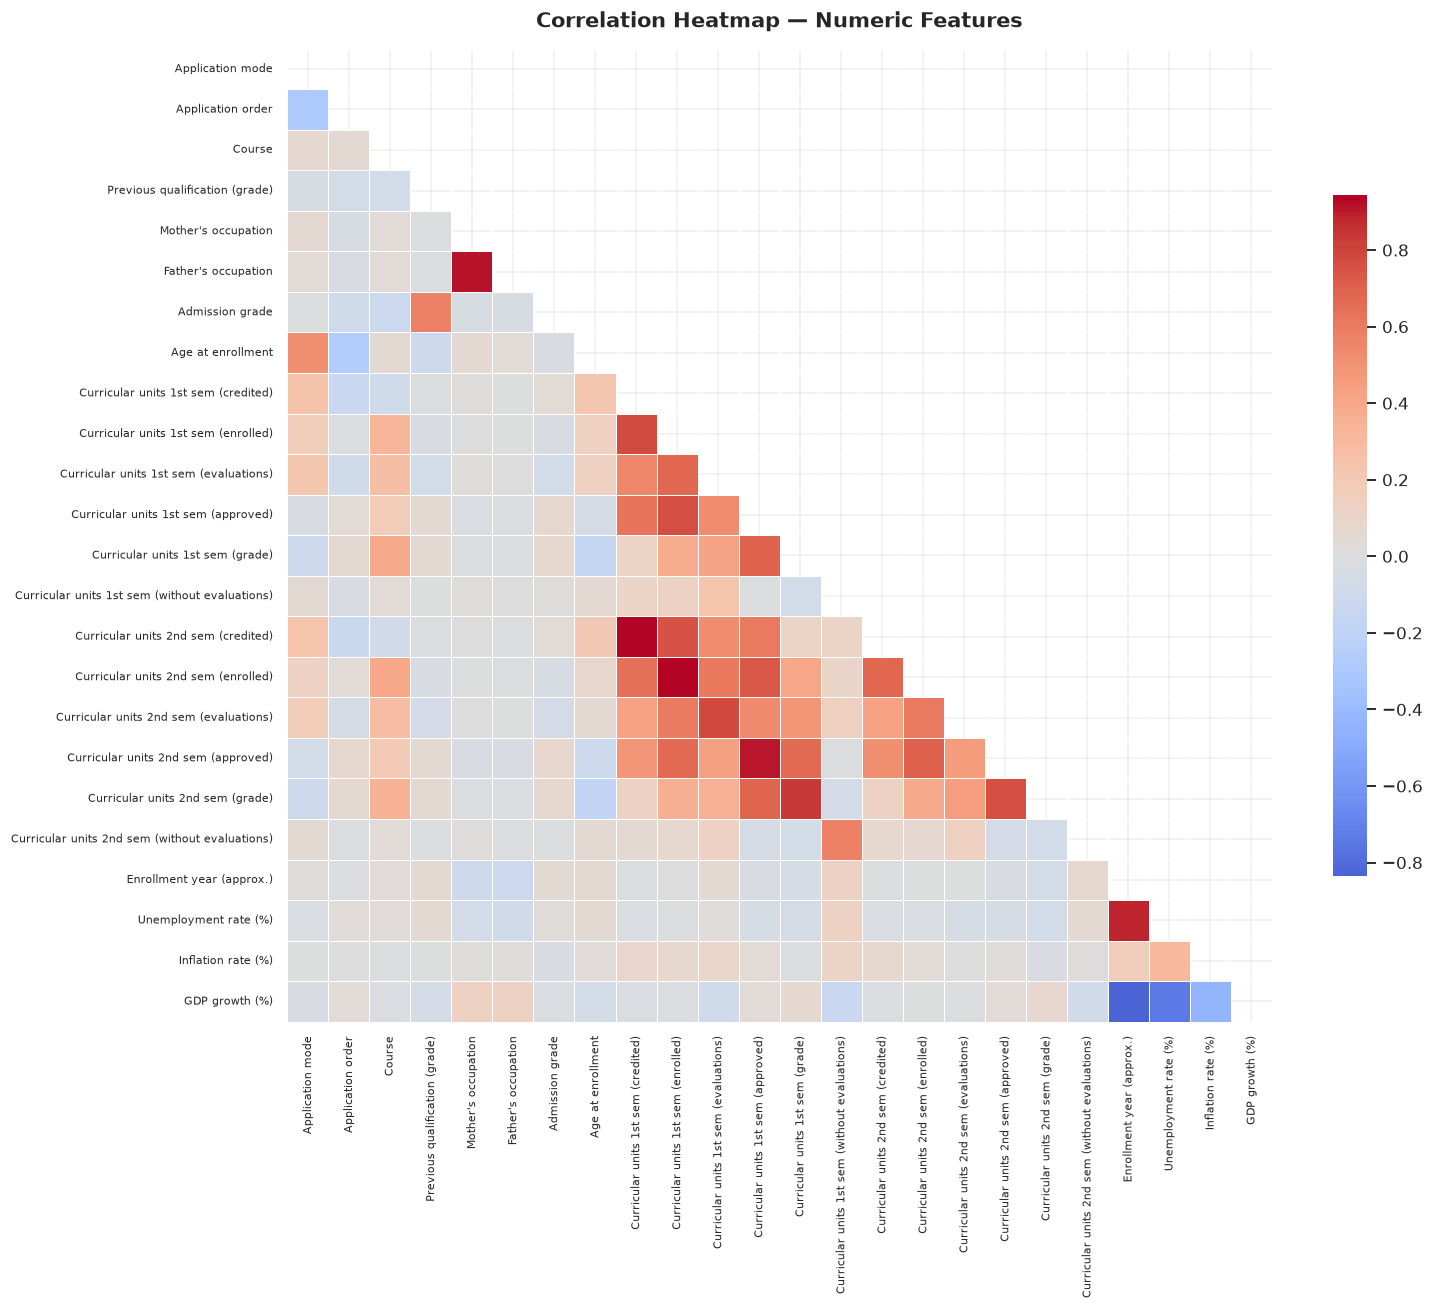

In [33]:
numeric_cols = df.select_dtypes(include="number").drop(columns=["Dropout"], errors="ignore")
corr = numeric_cols.corr()

# I mask the upper triangle since it's a mirror of the lower half — showing
# it twice was most of why this heatmap felt so cluttered before.
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0, ax=ax,
            cbar_kws={"shrink": 0.7}, linewidths=0.4, linecolor="white",
            xticklabels=True, yticklabels=True)
ax.set_title("Correlation Heatmap — Numeric Features", pad=14)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()

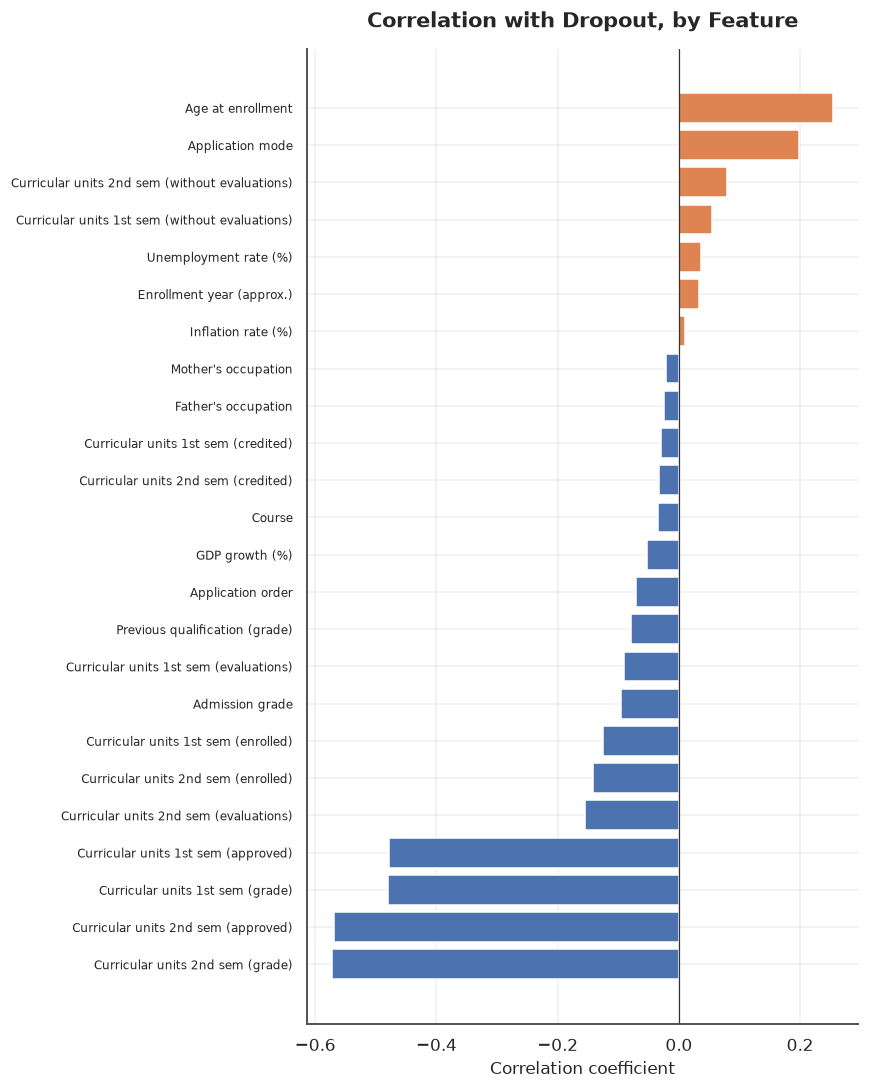

In [34]:
target_corr = (
    df.select_dtypes(include="number")
    .corr()["Dropout"]
    .drop("Dropout")
    .sort_values()
)

fig, ax = plt.subplots(figsize=(8, 10))
colors = [DROPOUT_COLOR if v > 0 else NOT_DROPOUT_COLOR for v in target_corr.values]
ax.barh(target_corr.index, target_corr.values, color=colors, edgecolor="white")
ax.axvline(0, color="#333333", linewidth=0.8)
ax.set_title("Correlation with Dropout, by Feature", pad=14)
ax.set_xlabel("Correlation coefficient")
ax.tick_params(axis="y", labelsize=8)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

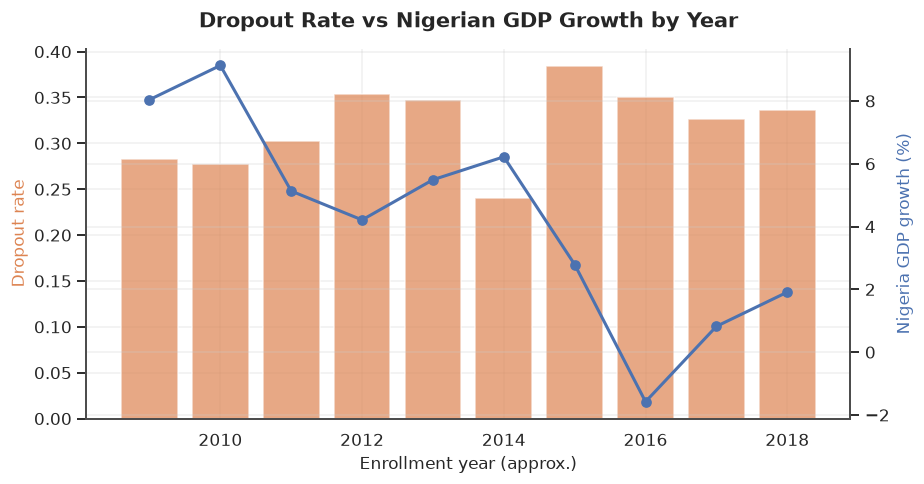

In [35]:
year_rate = df.groupby("Enrollment year (approx.)").agg(
    dropout_rate=("Dropout", "mean"),
    gdp_growth=("GDP growth (%)", "first"),
).reset_index()

fig, ax1 = plt.subplots(figsize=(8.5, 4.5))
ax2 = ax1.twinx()
ax1.bar(year_rate["Enrollment year (approx.)"], year_rate["dropout_rate"],
        color=DROPOUT_COLOR, alpha=0.7, label="Dropout rate", edgecolor="white")
ax2.plot(year_rate["Enrollment year (approx.)"], year_rate["gdp_growth"],
         color=NOT_DROPOUT_COLOR, marker="o", linewidth=2, label="GDP growth (%)")
ax1.set_ylabel("Dropout rate", color=DROPOUT_COLOR)
ax2.set_ylabel("Nigeria GDP growth (%)", color=NOT_DROPOUT_COLOR)
ax1.set_xlabel("Enrollment year (approx.)")
ax1.set_title("Dropout Rate vs Nigerian GDP Growth by Year", pad=14)
ax1.spines["top"].set_visible(False)
ax2.spines["top"].set_visible(False)
plt.tight_layout()
plt.show()

In [36]:
df = df.drop(columns=["Target", "Dropout_label"], errors="ignore")

df["Grade trend"] = (df["Curricular units 2nd sem (grade)"]
                      - df["Curricular units 1st sem (grade)"])

df["1st sem approval ratio"] = np.where(
    df["Curricular units 1st sem (enrolled)"] > 0,
    df["Curricular units 1st sem (approved)"] / df["Curricular units 1st sem (enrolled)"],
    0,
)
df["2nd sem approval ratio"] = np.where(
    df["Curricular units 2nd sem (enrolled)"] > 0,
    df["Curricular units 2nd sem (approved)"] / df["Curricular units 2nd sem (enrolled)"],
    0,
)

df["Financial risk score"] = (
    (df["Debtor"] == "Yes").astype(int)
    + (df["Tuition fees up to date"] == "No").astype(int)
    + (df["Scholarship holder"] == "No").astype(int)
)

df[["Grade trend", "1st sem approval ratio", "2nd sem approval ratio", "Financial risk score"]].describe()

,Grade trend,1st sem approval ratio,2nd sem approval ratio,Financial risk score
count,4424.000000,4424.000000,4424.000000,4424.000000
mean,-2.053323,0.697885,0.660356,0.984629
std,14.452047,0.365247,0.382964,0.730610
min,-80.700000,0.000000,0.000000,0.000000
25%,-3.000000,0.500000,0.400000,1.000000
50%,0.000000,0.833333,0.833333,1.000000
75%,2.300000,1.000000,1.000000,1.000000
max,80.000000,1.000000,1.000000,3.000000


In [37]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import (classification_report, f1_score, recall_score,
                              precision_recall_curve, accuracy_score, confusion_matrix)

RANDOM_SEED = 42

y = df["Dropout"]
X = df.drop(columns=["Dropout"])

categorical_cols = X.select_dtypes(include="object").columns.tolist()
numeric_cols = X.select_dtypes(include="number").columns.tolist()

X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
print(f"Features after encoding: {X_encoded.shape[1]}")

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

scaler = StandardScaler()
num_cols_present = [c for c in numeric_cols if c in X_train.columns]
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[num_cols_present] = scaler.fit_transform(X_train[num_cols_present])
X_test_scaled[num_cols_present] = scaler.transform(X_test[num_cols_present])

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train dropout rate: {y_train.mean():.3f}, Test dropout rate: {y_test.mean():.3f}")

/tmp/ipykernel_1555/753621109.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include="object").columns.tolist()


Features after encoding: 100
Train: (3539, 100), Test: (885, 100)
Train dropout rate: 0.321, Test dropout rate: 0.321


In [38]:
logreg = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_SEED)
logreg.fit(X_train_scaled, y_train)
pred_lr = logreg.predict(X_test_scaled)
print("=== Logistic Regression ===")
print(classification_report(y_test, pred_lr, target_names=["Not Dropout", "Dropout"]))

=== Logistic Regression ===
              precision    recall  f1-score   support

 Not Dropout       0.91      0.90      0.91       601
     Dropout       0.80      0.82      0.81       284

    accuracy                           0.87       885
   macro avg       0.85      0.86      0.86       885
weighted avg       0.88      0.87      0.88       885



In [39]:
rf = RandomForestClassifier(n_estimators=300, class_weight="balanced",
                             random_state=RANDOM_SEED, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
pred_rf = rf.predict(X_test_scaled)
print("=== Random Forest ===")
print(classification_report(y_test, pred_rf, target_names=["Not Dropout", "Dropout"]))

=== Random Forest ===
              precision    recall  f1-score   support

 Not Dropout       0.92      0.93      0.92       601
     Dropout       0.84      0.83      0.83       284

    accuracy                           0.89       885
   macro avg       0.88      0.88      0.88       885
weighted avg       0.89      0.89      0.89       885



In [40]:
import xgboost as xgb

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb_base = xgb.XGBClassifier(
    n_estimators=300, random_state=RANDOM_SEED, eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
)
xgb_base.fit(X_train_scaled, y_train)
pred_xgb = xgb_base.predict(X_test_scaled)
print("=== XGBoost (baseline) ===")
print(classification_report(y_test, pred_xgb, target_names=["Not Dropout", "Dropout"]))

=== XGBoost (baseline) ===
              precision    recall  f1-score   support

 Not Dropout       0.90      0.93      0.91       601
     Dropout       0.83      0.78      0.81       284

    accuracy                           0.88       885
   macro avg       0.87      0.85      0.86       885
weighted avg       0.88      0.88      0.88       885



In [41]:
ensemble = VotingClassifier(
    estimators=[("logreg", logreg), ("rf", rf), ("xgb", xgb_base)],
    voting="soft",
)
ensemble.fit(X_train_scaled, y_train)
pred_ens = ensemble.predict(X_test_scaled)
print("=== Ensemble (soft voting) ===")
print(classification_report(y_test, pred_ens, target_names=["Not Dropout", "Dropout"]))

=== Ensemble (soft voting) ===
              precision    recall  f1-score   support

 Not Dropout       0.91      0.92      0.91       601
     Dropout       0.82      0.80      0.81       284

    accuracy                           0.88       885
   macro avg       0.87      0.86      0.86       885
weighted avg       0.88      0.88      0.88       885



In [42]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=RANDOM_SEED)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)
print(f"After SMOTE, train dropout rate: {y_train_sm.mean():.3f} (n={len(y_train_sm)})")

param_dist = {
    "n_estimators": [200, 300, 400, 500],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5],
}
xgb_search = RandomizedSearchCV(
    xgb.XGBClassifier(random_state=RANDOM_SEED, eval_metric="logloss"),
    param_distributions=param_dist,
    n_iter=25,
    scoring="f1",
    cv=5,
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
xgb_search.fit(X_train_sm, y_train_sm)
best_xgb = xgb_search.best_estimator_
print(f"Best params: {xgb_search.best_params_}")

pred_best = best_xgb.predict(X_test_scaled)
print("\n=== Tuned XGBoost + SMOTE (default 0.5 threshold) ===")
print(classification_report(y_test, pred_best, target_names=["Not Dropout", "Dropout"]))

After SMOTE, train dropout rate: 0.500 (n=4804)
Best params: {'subsample': 0.9, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 0.8}

=== Tuned XGBoost + SMOTE (default 0.5 threshold) ===
              precision    recall  f1-score   support

 Not Dropout       0.91      0.94      0.93       601
     Dropout       0.86      0.81      0.83       284

    accuracy                           0.90       885
   macro avg       0.89      0.87      0.88       885
weighted avg       0.90      0.90      0.90       885



Best threshold for F1: 0.513

=== FINAL MODEL: Tuned XGBoost + SMOTE + threshold tuning ===
              precision    recall  f1-score   support

 Not Dropout       0.91      0.95      0.93       601
     Dropout       0.87      0.81      0.84       284

    accuracy                           0.90       885
   macro avg       0.89      0.88      0.88       885
weighted avg       0.90      0.90      0.90       885

Accuracy: 0.901
F1 (Dropout): 0.839
Recall (Dropout): 0.806

Confusion matrix:
[[568  33]
 [ 55 229]]


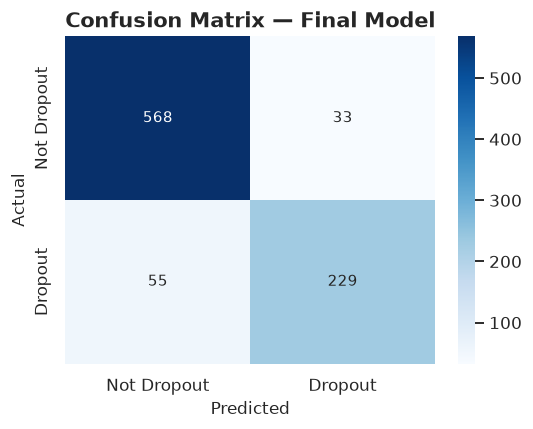

In [43]:


proba = best_xgb.predict_proba(X_test_scaled)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, proba)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]
print(f"Best threshold for F1: {best_threshold:.3f}")

pred_final = (proba >= best_threshold).astype(int)
print("\n=== FINAL MODEL: Tuned XGBoost + SMOTE + threshold tuning ===")
print(classification_report(y_test, pred_final, target_names=["Not Dropout", "Dropout"]))
print(f"Accuracy: {accuracy_score(y_test, pred_final):.3f}")
print(f"F1 (Dropout): {f1_score(y_test, pred_final):.3f}")
print(f"Recall (Dropout): {recall_score(y_test, pred_final):.3f}")

cm = confusion_matrix(y_test, pred_final)
print("\nConfusion matrix:")
print(cm)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Dropout", "Dropout"],
            yticklabels=["Not Dropout", "Dropout"], ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix — Final Model")
plt.tight_layout()
plt.show()


In [44]:
results = {
    "Logistic Regression": (accuracy_score(y_test, pred_lr), f1_score(y_test, pred_lr), recall_score(y_test, pred_lr)),
    "Random Forest": (accuracy_score(y_test, pred_rf), f1_score(y_test, pred_rf), recall_score(y_test, pred_rf)),
    "XGBoost (baseline)": (accuracy_score(y_test, pred_xgb), f1_score(y_test, pred_xgb), recall_score(y_test, pred_xgb)),
    "Ensemble": (accuracy_score(y_test, pred_ens), f1_score(y_test, pred_ens), recall_score(y_test, pred_ens)),
    "Tuned XGBoost+SMOTE (0.5)": (accuracy_score(y_test, pred_best), f1_score(y_test, pred_best), recall_score(y_test, pred_best)),
    "Tuned XGBoost+SMOTE+threshold": (accuracy_score(y_test, pred_final), f1_score(y_test, pred_final), recall_score(y_test, pred_final)),
}

comparison_df = pd.DataFrame(results, index=["Accuracy", "F1 (Dropout)", "Recall (Dropout)"]).T
comparison_df.round(3)

,Accuracy,F1 (Dropout),Recall (Dropout)
Logistic Regression,0.875,0.808,0.820
Random Forest,0.895,0.835,0.827
XGBoost (baseline),0.880,0.807,0.782
Ensemble,0.881,0.813,0.803
Tuned XGBoost+SMOTE (0.5),0.897,0.834,0.806
Tuned XGBoost+SMOTE+threshold,0.901,0.839,0.806


In [45]:
import joblib

# Save the final tuned model
joblib.dump(best_xgb, "dropout_model.pkl")

# Save the fitted scaler (needed to transform new inputs the same way)
joblib.dump(scaler, "scaler.pkl")

# Save the exact column order the model expects after one-hot encoding --
# critical, since a new prediction must match this exactly or predictions break
joblib.dump(list(X_encoded.columns), "feature_columns.pkl")

# Save defaults for any field the user doesn't provide -- same approach
# your predict_dropout_risk() function already uses
joblib.dump(X[categorical_cols].mode().iloc[0].to_dict(), "categorical_defaults.pkl")
joblib.dump(X[numeric_cols].median().to_dict(), "numeric_defaults.pkl")

# Save the tuned decision threshold -- NOT 0.5, this is what you optimized for
joblib.dump(float(best_threshold), "decision_threshold.pkl")

# Save which columns are categorical vs numeric, and the list before encoding
joblib.dump(categorical_cols, "categorical_cols.pkl")
joblib.dump(numeric_cols, "numeric_cols.pkl")

print("Saved: dropout_model.pkl, scaler.pkl, feature_columns.pkl,")
print("       categorical_defaults.pkl, numeric_defaults.pkl,")
print("       decision_threshold.pkl, categorical_cols.pkl, numeric_cols.pkl")

Saved: dropout_model.pkl, scaler.pkl, feature_columns.pkl,
       categorical_defaults.pkl, numeric_defaults.pkl,
       decision_threshold.pkl, categorical_cols.pkl, numeric_cols.pkl
